# Aprenentatge no supervisat

Al contrari que el supervisat, el no supervisat treballa en datasets `no etiquetats`, és a dir sense `target`. 

L'objectiu és classificar les observacions, als distints grups els podem posar després, o no, etiquetes. 

Com a part del procés es poden detectar dades que no corresponen a cap classe. Això són anomalíes o `outliers`. De vegades els outliers molesten per al bon funcionament dels models, de vegades podem utilitzar aquests algorismes per detectar outliers per a altres algorismes supervisats i de vegades estarem fen els models perquè el que ens interessa és precisament detectar les anomalies. 

Els sistemes de *clustering* funcionen avaluant la similitud o **afinitat** entre diferents observacions o respecte a un grup ja existent. Com major siga esta afinitat, més probable serà que s'integreguen en el mateix conjunt. El seu propòsit fonamental es dividix en dos objectius complementaris:

1. **Alta cohesió:** Aconseguir la màxima similitud possible entre els elements que formen part d'un mateix clúster.
2. **Baix acoblament:** Garantir la mínima relació o afinitat entre els components de clústers diferents.

La gran majoria d'estos algorismes comparteixen un caràcter **iteratiu** perquè s'enfoquen com a problemes d'optimització. El procés habitual seguix estos passos:

* Es partix d'una **solució inicial** (que pot ser completament aleatòria), assignant les observacions a diferents grups.
* Esta distribució inicial es va **refinant pas a pas** en successives iteracions.
* Alguns mètodes exigeixen definir el nombre de clústers per endavant, mentre que uns altres el poden modificar en temps d'execució (per exemple, fusionant grups).
* El procés finalitza quan s'arriba a un punt d'estabilitat —on l'assignació de les dades ja no canvia— o quan es complix un requisit mínim de qualitat.

Avaluar la qualitat del clustering és una tasca quasi comú a tots els algorismes. Hi ha diverses tècniques com el SSD o SSE, inèrcia, la silueta, entre altres. En els exemples quasi sempre veurem problemes amb 2 variables que poden ser representats en un gràfic, però normalment els problemes reals tenen més dimensions i no podem avaluar visualment la qualitat del resultat, per tant cal confiar més en mesures matemàtiques rigoroses junt al **coneixement del negoci**. 

L'agrupació de dades sense etiquetar es pot dur a terme amb el mòdul `sklearn.cluster`. Cada algorisme d'agrupació es presenta en dues variants: una classe, que implementa el mètode d'ajust per aprendre els clústers sobre les dades d'entrenament, i una funció, que, donades les dades d'entrenament, retorna una matriu d'etiquetes enteres corresponents als diferents clústers. Per a la classe, les etiquetes sobre les dades d'entrenament es poden trobar a l'atribut `labels_`.

## Tipus principals d'algorismes

* **1. K-Means (Basat en distàncies)**

Cada clúster està definit per un **centroide** (el seu punt central). Cada dada s'assigna al grup del centroide que té més a prop. A continuació, es recalculen les coordenades dels centroides fent la mitjana aritmètica de totes les dades d'eixe clúster. El cicle es repeteix fins que cap dada canvia de grup. Requereix fixar prèviament el nombre de clústers ($k$) i triar uns centres inicials de manera arbitrària.

* **2. FCM: Fuzzy C-Means (Basat en lògica difusa)**

És una evolució de K-Means. En lloc de vincular una dada a un únic clúster de forma absoluta, utilitza funcions matemàtiques per a calcular la **probabilitat de pertinença** a cada grup. Finalment, cada observació s'associa al clúster on esta funció de pertinença prenga el valor màxim.

* **3. DBSCAN (Basat en densitat)**

Agrupa en un mateix clúster aquells punts situats en **zones d'alta concentració** de dades (amb molts veïns pròxims). Per contra, classifica com a valors atípics o *outliers* tots aquells punts situats en regions aïllades o de baixa densitat.

* **4. Clústering jeràrquic**

Genera una estructura de grups en forma d'arbre que es pot visualitzar mitjançant un **dendrograma**, on la base o arrel és el conjunt complet de dades i els nivells inferiors formen particions cada vegada més específiques. Pot funcionar de dos formes:

* **Aglomeratiu (*bottom-up*):** Es comença considerant cada dada com un clúster independent i s'aniran unint progressivament de baix a dalt.
* **Divisiu (*top-down*):** Es comença amb un únic clúster que abasta tot el *dataset* i s'anirà dividint successivament de dalt a baix.

## K-Means

Aquest algorisme de `clustering` es basa en la distància. El que es fa es definir un `centroid` que és el punt central d'un cluster. Cada observació es assignada al cluster que té el centroid més proper. 

El centroid és la mitjana aritmètica de totes les observacions del cluster. 

La dificultat d'aquest algorisme és determinar els centroids:

- Es trien k dades com a centroids. 
- S'assigna cada dada al centroid més proper, per tant tenim k grups.
- Si en el pas anterior hi ha algun canvi de grup, el torna a obtenir el centroid de cada grup que ha canviat i es torna al pas anterior. 

https://www.unioviedo.es/compnum/labs/new/kmeans.html

El següent exemple és per visualitzar el procés de l'algorisme:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from IPython.display import HTML

# 1. Generació de dades sintètiques en 2 dimensions
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0)

# 2. Configuració prèvia de K-means per capturar els passos
k = 4
max_iter = 10

# Guardarem els centroides de cada iteració per animar-los
centroids_history = []
labels_history = []

# Inicialització aleatòria dels centroides (pertorbats per forçar iteracions)
init_centroids = X[np.random.choice(X.shape[0], k, replace=False)] + np.random.normal(scale=3.0, size=(k, X.shape[1]))
current_centroids = init_centroids.copy()

for i in range(max_iter):
    # Assignar clústers basats en els centroides actuals, això no cal fer-ho manualment, ja que KMeans ho fa internament millor.
    kmeans = KMeans(n_clusters=k, init=current_centroids, n_init=1, max_iter=1)
    kmeans.fit(X)
    
    labels_history.append(kmeans.labels_)
    centroids_history.append(kmeans.cluster_centers_)
    
    # Comprovar si els centroides han deixat de moure'ixer (convergent)
    if np.allclose(current_centroids, kmeans.cluster_centers_):
        break
    current_centroids = kmeans.cluster_centers_

# 3. Configuració de la figura de Matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
scat = ax.scatter(X[:, 0], X[:, 1], c=labels_history[0], cmap='viridis', s=50, alpha=0.7)
cent_scat = ax.scatter(centroids_history[0][:, 0], centroids_history[0][:, 1], 
                       c='red', marker='X', s=200, edgecolor='black', label='Centroides')

ax.set_title('Evolució de K-Means (Pas 0)', fontsize=14)
ax.set_xlabel('Característica 1')
ax.set_ylabel('Característica 2')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# 4. Funció d'actualització per a l'animació
def update(frame):
    # Actualitzar els colors dels punts segons l'assignació del clúster
    scat.set_array(np.array(labels_history[frame]))
    
    # Actualitzar la posició dels centroides
    cent_scat.set_offsets(centroids_history[frame])
    
    ax.set_title(f'Evolució de K-Means - Iteració {frame + 1}', fontsize=14)
    return scat, cent_scat

# Crear l'animació
anim = FuncAnimation(fig, update, frames=len(centroids_history), interval=800, blit=False)

# Tancar la figura estàtica per evitar que es mostri doble al notebook
plt.close()

# 5. Mostrar l'animació directament al Jupyter Notebook
HTML(anim.to_jshtml())

La distància normalment és `euclídea`, que en 2 dimensions és bàsicament la hipotenusa del teorema de Pitàgores. 

No obstant es pot utilitzar la distància `Manhathan`, que és la suma dels catets. 

Per a fer clustering en conjunts de paraules es pot utilitzar la distància de `Hamming` que miren en dos cadenes de caracters el número de caraters diferents. 

La distància `Levenshtein` és la quantitat mínima d'operacions a realitzar en una cadena de caracters per transformar-la en l'altra. És un càlcul computacionalment complex.

### Avaluar k-Means

La qualitat del resultat es basa en la suma dels quadrats de les distàncies respecte al centroid del cluster. La mesura es diu `SSD` (`Sum of Squared Distancies`) o `SSE` (`Sum of Squared Errors`) o també `inèrcia`.

Precisament l'algorisme el que tracta és de minimitzar aquesta mesura de manera iterativa. Però pot ser que no trobe un mínim global, sols un mínim global. 

> La simulació anterior de vegades mostra com no es troba un mínim global si els centroids inicials aleatoris no cauen en un bon lloc. 

Els clusters tenen una frontera recta i formen diagrames `Voronoi`. Per tant, un resultat perfecte requereix que siguen `linealment separables`. És possible que siguen linealment separables i que no es puguen separar amb aquest algorisme, ja que amb atributs no normalitzats o distants, poden semblar ser de l'altre cluster. 

Amb clusters `globulars` funciona molt millor que allargats o amb formes irregulars. Si són allargats en distintes direccions pot no ser possible separar els clústers. 

> Al següent exemple es generen grups amb make_classification que ens permet generar clústers amb geometries orientades o lleugerament lineals (més enllà dels clústers purament esfèrics o globulars dels blobs clàssics). D'altra banda, si el nostre objectiu és demostrar les limitacions evidents de K-Means, la documentació de Scikit-Learn ens ofereix generadors d'estructures no lineals i no convexes —com make_moons per a formes de mitja lluna o make_gaussian_quantiles per a anells concèntrics—, on l'algorisme fracassa perquè les seves fronteres de Voronoi basades en distàncies euclidianes no s'hi poden adaptar.

L'inèrcia no és una mesura molt fiable en casos complexos de molta dimensionalitat. En eixos casos es pot fer una `reducció de dimensionalitat` amb `PCA` o avaluar amb altres tècniques. 

![problemes kmeans](./imgs_cluster/sphx_glr_plot_kmeans_assumptions_002.png)

[Exemples](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_assumptions.html#sphx-glr-auto-examples-cluster-plot-kmeans-assumptions-py)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_classification
from sklearn.cluster import KMeans
from IPython.display import HTML

# 1. Generar dues subpoblacions amb make_classification per sumar 5 clústers en total (2 + 3)
X1, _ = make_classification(
    n_samples=150, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_classes=2, 
    n_clusters_per_class=1, 
    class_sep=3.0, 
    #random_state=42
)
# Desplacem el primer grup lleugerament per evitar que se superposin massa
X1 = X1 + np.array([-3.0, 0.0])

X2, _ = make_classification(
    n_samples=150, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_classes=3, 
    n_clusters_per_class=1, 
    class_sep=2.0, 
    #random_state=24
)
# Desplacem el segon grup a una altra zona de l'espai 2D
X2 = X2 + np.array([3.0, 0.0])

# Unim ambdós conjunts en una sola matriu de 300 mostres i 2 dimensions
X = np.vstack([X1, X2])

# Total de clústers desitjats (2 + 3 = 5)
k = 5

# 2. Configuració de K-means i captura d'històric
max_iter = 15 
centroids_history = []
labels_history = []

#np.random.seed(42)
init_indices = np.random.choice(X.shape[0], k, replace=False)
current_centroids = X[init_indices]

for i in range(max_iter):
    kmeans = KMeans(n_clusters=k, init=current_centroids, n_init=1, max_iter=1)
    kmeans.fit(X)
    
    labels_history.append(kmeans.labels_)
    centroids_history.append(kmeans.cluster_centers_)
    
    if np.allclose(current_centroids, kmeans.cluster_centers_):
        break
    current_centroids = kmeans.cluster_centers_

# 3. Configuració de la figura i creació del Meshgrid per a Voronoi
fig, ax = plt.subplots(figsize=(9, 7))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.15),
                     np.arange(y_min, y_max, 0.15))

# 4. Funció d'actualització
def update(frame):
    ax.clear()  
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    current_centers = centroids_history[frame]
    
    # Calcular les regions de Voronoi per a la iteració actual
    distances = np.linalg.norm(np.c_[xx.ravel(), yy.ravel()][:, np.newaxis] - current_centers, axis=2)
    Z = np.argmin(distances, axis=1).reshape(xx.shape)
    
    # Dibuixar el fons de Voronoi
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', zorder=0)
    
    # Dibuixar els punts de dades combinats
    ax.scatter(X[:, 0], X[:, 1], c=labels_history[frame], cmap='viridis', s=40, edgecolor='k', alpha=0.9, zorder=1)
    
    # Dibuixar els centroides
    ax.scatter(current_centers[:, 0], current_centers[:, 1], 
               c='red', marker='X', s=250, edgecolor='black', label='Centroides', zorder=2)
    
    ax.set_title(f'K-Means amb {k} Clústers Combinats (2+3 Make-Classification) - Iteració {frame + 1}', fontsize=14)
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

# Crear l'animació
anim = FuncAnimation(fig, update, frames=len(centroids_history), interval=1000, blit=False)

plt.close()

# 5. Mostrar l'animació
HTML(anim.to_jshtml())

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from IPython.display import HTML

# Nombre de clústers
k = 2

# 1. Generació de dades amb make_moons per a 2 clústers irregulars
X, _ = make_moons(n_samples=300, noise=0.08)

# 2. Configuració de K-means i captura d'històric
max_iter = 15 
centroids_history = []
labels_history = []


init_indices = np.random.choice(X.shape[0], k, replace=False)
current_centroids = X[init_indices]

for i in range(max_iter):
    kmeans = KMeans(n_clusters=k, init=current_centroids, n_init=1, max_iter=1)
    kmeans.fit(X)
    
    labels_history.append(kmeans.labels_)
    centroids_history.append(kmeans.cluster_centers_)
    
    if np.allclose(current_centroids, kmeans.cluster_centers_):
        break
    current_centroids = kmeans.cluster_centers_

# 3. Configuració de la figura i creació del Meshgrid per a Voronoi
fig, ax = plt.subplots(figsize=(9, 7))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.15),
                     np.arange(y_min, y_max, 0.15))

# 4. Funció d'actualització
def update(frame):
    ax.clear()  
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    current_centers = centroids_history[frame]
    
    # Calcular les regions de Voronoi per a la iteració actual
    distances = np.linalg.norm(np.c_[xx.ravel(), yy.ravel()][:, np.newaxis] - current_centers, axis=2)
    Z = np.argmin(distances, axis=1).reshape(xx.shape)
    
    # Dibuixar el fons de Voronoi
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', zorder=0)
    
    # Dibuixar els punts de dades de make_moons
    ax.scatter(X[:, 0], X[:, 1], c=labels_history[frame], cmap='viridis', s=40, edgecolor='k', alpha=0.9, zorder=1)
    
    # Dibuixar els centroides
    ax.scatter(current_centers[:, 0], current_centers[:, 1], 
               c='red', marker='X', s=250, edgecolor='black', label='Centroides', zorder=2)
    
    ax.set_title(f'K-Means amb Make-Moons (k={k}) i Voronoi - Iteració {frame + 1}', fontsize=14)
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

# Crear l'animació
anim = FuncAnimation(fig, update, frames=len(centroids_history), interval=1000, blit=False)

plt.close()

# 5. Mostrar l'animació
HTML(anim.to_jshtml())

### Elecció de centroids

Hi ha varis plantejaments:

* Triar el centroid amb més distància al quadrat de la resta de tots els punts i els següent el més llunyà d'aquest. Funciona bé, però té tendència a triar `outliers`. Si els detectem i els llevem primer, és un bon algorisme. 
* Triar a l'atzar però afavorint punts llunyans del centroid anterior. Això evita triar `outliers`. 

A `scikit-learn` està `kmeans++` com a paràmetre `init` per defecte que inicialitza segons el segon mètode.

### Elecció de k

> En aquest punt i els exemples següents anem a triar la manera més simple. Després expliquem perquè i al final d'aquest capítol veurem en pràctica mètodes més sofisticats.

El que es pot fer és executar l'algorisme amb distints valors i triar el que menor `SSD` dona. Si es fa una gràfica del `SSD` en funció de `k` es diu `elbow graphic`. Quant es troba que ja no millora molt (el colze) es triar el valor menor. Normalment interessa la menor quantitat possible de clusters.  

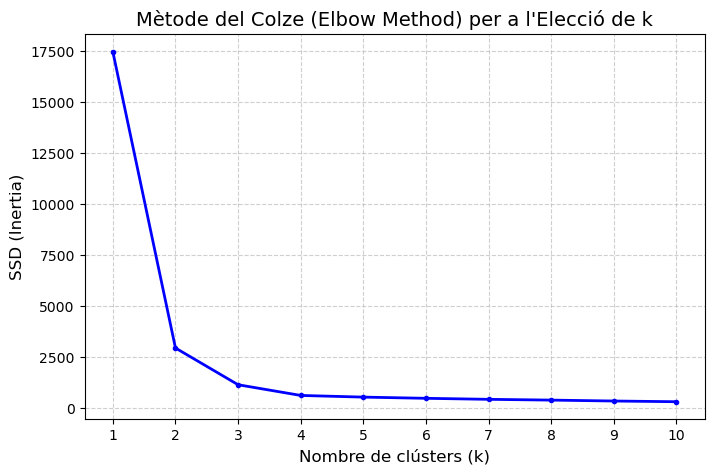

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# 1. Generació de dades amb
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0)

# 2. Càlcul del SSD (Inertia) per a diferents valors de k (Elbow Method)
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# 3. Representació gràfica del mètode del colze (Elbow Graphic)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, marker='o', linestyle='-', color='b', linewidth=2, markersize=3)
ax.set_title("Mètode del Colze (Elbow Method) per a l'Elecció de k", fontsize=14)
ax.set_xlabel('Nombre de clústers (k)', fontsize=12)
ax.set_ylabel('SSD (Inertia)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.xticks(K_range)

plt.show()

La manera de triar el millor punt de forma automàtica i no a ull pot ser:

* La segona derivada de la curva (El següents exemples): La primera derivada indica el ritme de creixement en un punt. La segona derivada detecta la variació en el ritme. Per tant el valor màxim de la segona derivada és el punt on més canvia el ritme i per tant el colze. És una tècnica simple però rudimentaria que falla amb una quantitat major de uns 10 clusters, colzes no tant pronunciats o k=2. 
* Inèrcia (SSD): kmeans.inertia_ (integrat a l'objecte KMeans). Inertia forma par de KMeans perquè és par de l'algorisme i la manera de recalcular el centroids. 

Però hi ha altres maneres millors de trobar la quantitat ideal de clústers:

* Silhouette Score: from sklearn.metrics import silhouette_score
* Calinski-Harabasz Index: from sklearn.metrics import calinski_harabasz_score
* Davies-Bouldin Index: from sklearn.metrics import davies_bouldin_score


### Taula Comparativa de Mètriques de Clúster

| Mètrica | Què avalua / Com funciona | Com s'interpreta | Avantatges principals | Limitacions principals |
| --- | --- | --- | --- | --- |
| **Inertia (SSD)** i Elbow | Mesura la suma de les distàncies al quadrat de cada punt fins al seu centroide. | **Menys és millor** (s'acosta a 0). | Molt intuïtiva; és la base directa de l'algorisme K-Means. | Sempre baixa a mesura que augmenta $k$ (té un mínim trivial si $k = n$ mostres), exigint buscar un "colze". |
| **Silhouette Score** | Compara com de proper està un punt a la seva pròpia classe respecte a la resta de classes. | **Més alt és millor** (va de -1 a +1). | Té una escala fixa i clara; penalitza superposicions evidents. | Computacionalment molt costosa en conjunts de dades grans ($O(n^2)$); afavoreix clústers globulars. |
| **Calinski-Harabasz** *(Ratio de Variança)* | Relació entre la dispersió *entre* clústers i la dispersió *dins* dels clústers. | **Més alt és millor**. | Molt ràpida de calcular i computacionalment eficient. | Sol donar valors més alts per a clústers convexos o esfèrics estandarditzats. |
| **Davies-Bouldin** | Calcula la "similitud" mitjana de cada clúster amb el seu clúster més proper (compara la distància interna amb la distància entre centroides). | **Menys és millor** (el valor mínim és 0). | Fàcil d'interpretar: valors propers a 0 indiquen clústers ben separats i compactes. | Sensible a valors atípics (*outliers*) i assumeix formes convexes o esfèriques. |

https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py 

L'inèrcia es considera obsoleta perquè:

* **És una mètrica purament monòtona:** Com que l'inèrcia sempre baixa a mesura que augmenta $k$ (arribant a zero si $k$ és igual al nombre de mostres), no té un valor òptim universal ni un límit fix. Interpretar visualment un "colze" és subjectiu, ambigu i impossible d'automatitzar de manera fiable en pipelines de dades.
* **Manca de suport teòric sòlid:** 
* **No avalua la separació real:** L'inèrcia només mesura la compactesa interna (*com de junts estan els punts del seu centroide*), però ignora completament si els clústers resultants s'estan encimallant o superposant amb els veïns.

**Què s'utilitza realment en producció?**

1. **Criteri de negoci o restriccions pràctiques:** En molts projectes reals, el valor de $k$ no es calcula matemàticament, sinó que ve donat pel negoci (per exemple: *"necessitem segmentar els clients en exactament 4 tipus de perfils comercials perquè l'equip de màrqueting només pot gestionar 4 campanyes diferents"*).
2. **Validació amb Silhouette Score o Davies-Bouldin:** Si s'ha de calcular de manera automatitzada o quantitativa, s'opta per mètriques que avaluen tant la cohesió interna com la separació externa (com la silueta), o directament s'utilitzen algorismes que no requereixen fixar $k$ prèviament, com **DBSCAN** o **HDBSCAN**.

### Exemple complet de k-Means

Al següent repositori tenim alguns datasets sintètics que poden ser interessants per probar algorismes: https://github.com/deric/clustering-benchmark 

Utilitzarem un d'ells

In [107]:
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans

!rm 2d-4c-no9.arff
!wget https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/2d-4c-no9.arff

rm: no se puede borrar '2d-4c-no9.arff': No existe el archivo o el directorio
--2026-07-27 16:23:48--  https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/2d-4c-no9.arff
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.110.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 17117 (17K) [text/plain]
Guardando como: ‘2d-4c-no9.arff’

2d-4c-no9.arff      100%[===================>]  16,72K  --.-KB/s    en 0,001s  

2026-07-27 16:23:48 (10,9 MB/s) - ‘2d-4c-no9.arff’ guardado [17117/17117]



In [112]:
valores, metad = arff.loadarff("2d-4c-no9.arff")
df = pd.DataFrame(valores)
df.info()

atr_x = "a0"
atr_y = "a1"



<class 'pandas.DataFrame'>
RangeIndex: 876 entries, 0 to 875
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a0      876 non-null    float64
 1   a1      876 non-null    float64
 2   class   876 non-null    object 
dtypes: float64(2), object(1)
memory usage: 20.7+ KB


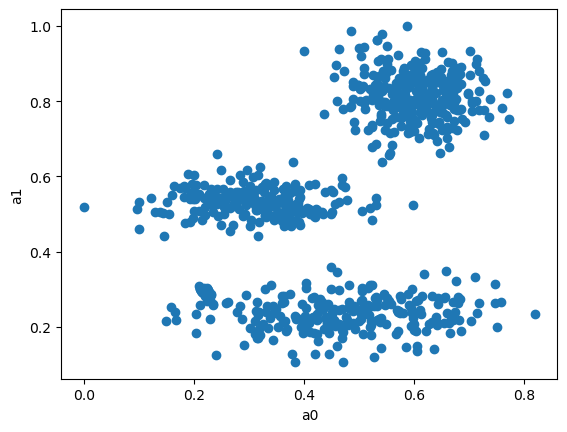

In [113]:
df_0 = df.copy()
df = df.drop(["class"], axis=1)  # Eliminem la columna de classe per a l'agrupament no supervisat

# Normalització de les dades per a l'agrupament no supervisat
df = (df-np.min(df))/(np.max(df)-np.min(df))
x=df[atr_x]
y=df[atr_y]


plt.scatter(x, y)
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()


A simple vista els clusters estan prou diferenciats i separats, no són totalment globulars, però tenen formes regulars que els fan linealment separables. K-Means pot funcionar bé. 

In [ ]:
# Corba de colze (elbow curve) per a k-means mostra els errors quadràtics mitjans
# per a cada valor de k (nombre de clústers)

scores = []
n = 20 # Número de repliques, aplica l'algorisme n vegades amb diferents inicialitzacions i agafa la millor solució (la que minimitza l'SSD)
rango_k = range(1,15)
for k in rango_k:
  kmeans = KMeans(n_clusters = k, n_init = n, random_state = 5, verbose = 0)
  kmeans.fit(df)
  scores.append(kmeans.inertia_)



Codo: k= 3


(0.0, 81.70762942314187)

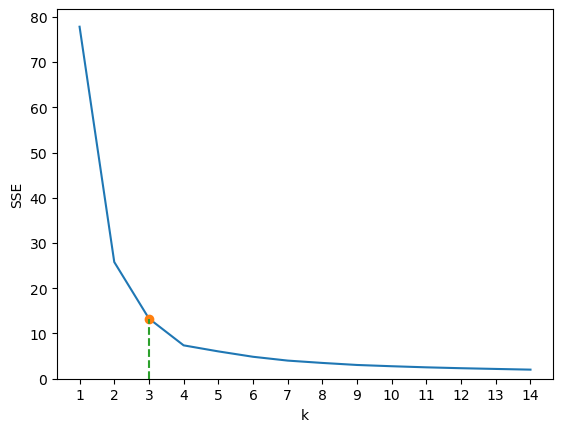

In [ ]:
# Localització del colze per aproximació de la segona derivada.
#
# SSE'' (segona derivada de SSE) s'aproxima per
# SSE''(i) = (SSE(i+1)-SSE(i))-(SSE(i)-SSE(i-1)) = SSE(i+1)+SSE(i-1)-2*SSE(i)
#
# El colze és on el valor absolut de la segona derivada és màxim, és
# dir, on és màxim abs(2*SSE(i)-SSE(i+1)-SSE(i-1))

# Ja hem dit que no és la millor manera, ja que cal utilitzar la silueta, 
#  però ho deixem així per a mostrar el mètode del colze.

abs_der2 = [0, 0]
for i in range(2, len(scores)-1):
  abs_der2.append(np.abs(2*scores[i]-scores[i+1]-scores[i-1]))

elbow = pd.Series(abs_der2).idxmax() + 1

print("Codo: k=", elbow)

plt.xlabel("k")
plt.ylabel("SSE")
plt.xticks(np.arange(rango_k.start,rango_k.stop,1))
plt.plot(rango_k, scores)
plt.plot(elbow, scores[elbow-1], marker = "o")
plt.plot([elbow, elbow], [0, scores[elbow-1]], linestyle="--")
plt.ylim(ymin=0)

Centroides:
 [[0.60132069 0.81157774]
 [0.28037551 0.44517186]
 [0.49776151 0.23203223]]
Grupo 0:  313 observaciones
Grupo 1:  339 observaciones
Grupo 2:  224 observaciones


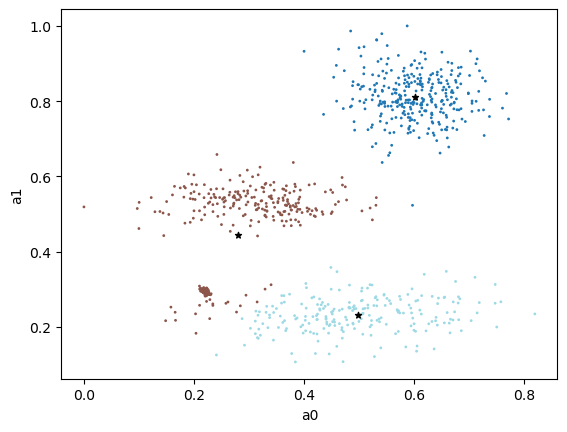

Score: 13.303508


In [ ]:
k = 3
n = 20    # Número de répliques

kmeans = KMeans(n_clusters = k, n_init = n, random_state = 5, verbose = 0)

kmeans.fit(df)
grupos = kmeans.predict(df)
centroides = kmeans.cluster_centers_

print("Centroides:\n", centroides)

# Mostrar grupos

for i in range(kmeans.n_clusters):
  print("Grupo {:d}: {:4d} observaciones".format(i, sum(grupos==i)))

plt.scatter(x, y, c=grupos, s=1, cmap='tab20')

# Marcar centroides

plt.scatter(centroides[:, 0], centroides[:, 1], marker='*', c='black', s=20)

plt.xlabel(atr_x)
plt.ylabel(atr_y)

plt.show()

print("Score: {:f}".format(kmeans.inertia_))


Es veu que el clúster no és satisfactori amb punts que no semblen correspondre al clúster. El problema és que el grup de baix és molt llarg. Amb un reescalar de `x` passaran a ser més pareguts a `blobs` i millorarà el centroid del grup del mig. 


Centroides:
 [[0.00993939 0.53477297]
 [0.01254667 0.25152236]
 [0.01880241 0.81455431]]
Grupo 0:  223 observaciones
Grupo 1:  345 observaciones
Grupo 2:  308 observaciones


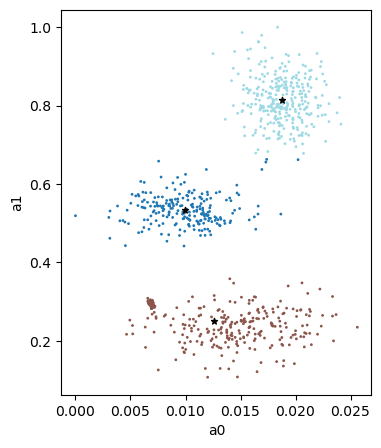

Score: 2.193830


In [126]:
df[atr_x] = df[atr_x]*0.5
x=df[atr_x]
y=df[atr_y]

k = 3
n = 20    # Número de réplicas



kmeans = KMeans(n_clusters = k, n_init = n, random_state = 5, verbose = 0)

kmeans.fit(df)
grupos = kmeans.predict(df)
centroides = kmeans.cluster_centers_

print("Centroides:\n", centroides)

# Mostrar grupos

for i in range(kmeans.n_clusters):
  print("Grupo {:d}: {:4d} observaciones".format(i, sum(grupos==i)))


fig, ax = plt.subplots(figsize=(4, 5))

ax.scatter(x, y, c=grupos, s=1, cmap='tab20')


# Marcar centroides

ax.scatter(centroides[:, 0], centroides[:, 1], marker='*', c='black', s=20)

ax.set_xlabel(atr_x)
ax.set_ylabel(atr_y)

plt.show()

print("Score: {:f}".format(kmeans.inertia_))


Aquest exemple està molt preparat i sols amb 2 dimensions. No sempre serà tant fàcil. A partir de 4 dimensions no es pot representar, però sempre es pot fer la gràfica del colze SSE i les tècniques més avançades que després veurem.



### Exemple de K-Means en 3D



In [127]:
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

!rm tetra.arff
!wget https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/tetra.arff

rm: no se puede borrar 'tetra.arff': No existe el archivo o el directorio
--2026-07-27 16:44:58--  https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/tetra.arff
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.109.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 12727 (12K) [text/plain]
Guardando como: ‘tetra.arff’

tetra.arff          100%[===================>]  12,43K  --.-KB/s    en 0,001s  

2026-07-27 16:44:58 (10,2 MB/s) - ‘tetra.arff’ guardado [12727/12727]



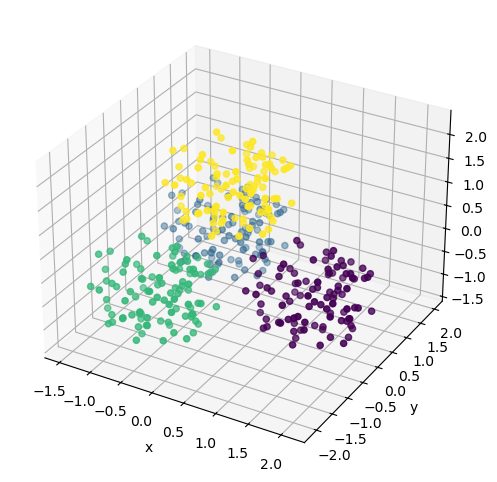

Codo: k= 4


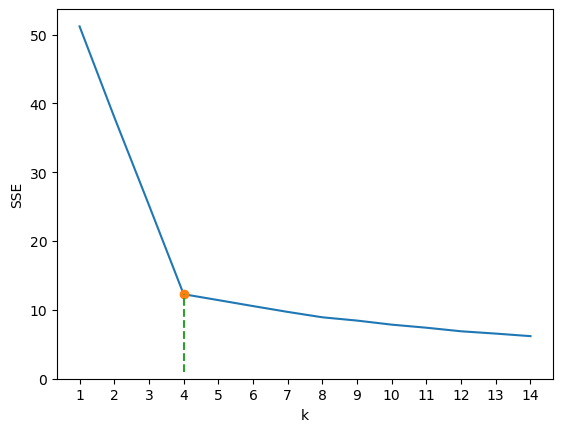

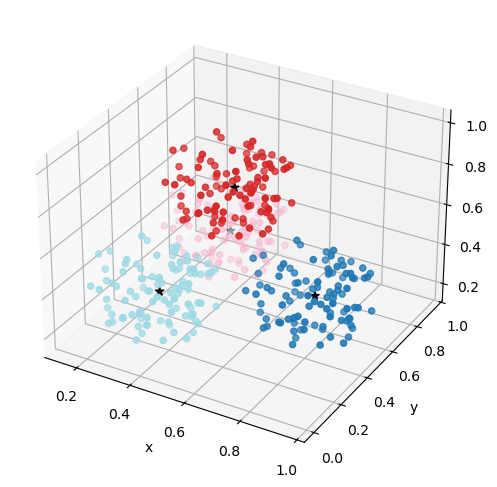

In [132]:
valores, metad = arff.loadarff("tetra.arff")
df = pd.DataFrame(valores)

attr_x='x'
attr_y='y'
attr_z='z'
attr_target='class'

ax = plt.figure().add_subplot(projection = '3d')
plt.gcf().set_size_inches(8, 6)
ax.set_xlabel(attr_x)
ax.set_ylabel(attr_y)
ax.set_zlabel(attr_z)
scatter = ax.scatter(df[attr_x], df[attr_y], df[attr_z], c=df[attr_target])
plt.show()

df_0 = df
df = df.drop(["class"], axis=1)

df = (df-np.min(df))/(np.max(df)-np.min(df))

# Curva de codo (elbow curve) para k-means muestra los errores cuadráticos
# medios para cada valor de k (número de clusters).

RANDOM_SEED = 5
n=20

scores = []
rango_k = range(1,15)
for k in rango_k:
  kmeans = KMeans(n_clusters = k, n_init = n, random_state = 5, verbose = 0)
  kmeans.fit(df)
  scores.append(kmeans.inertia_)


abs_der2 = [0, 0]
for i in range(2, len(scores)-1):
  abs_der2.append(np.abs(2*scores[i]-scores[i+1]-scores[i-1]))

codo = pd.Series(abs_der2).idxmax() + 1
print("Codo: k=", codo)


plt.xlabel("k")
plt.ylabel("SSE")
plt.xticks(np.arange(rango_k.start,rango_k.stop,1))
plt.plot(rango_k, scores)
plt.plot(codo, scores[codo-1], marker = "o")
plt.plot([codo, codo], [1, scores[codo-1]], linestyle="--")
plt.ylim(ymin=0)

k = 4
n = 20    # Número de réplicas

kmeans = KMeans(n_clusters = k, n_init = n, random_state = RANDOM_SEED, verbose = 0)

kmeans.fit(df)
grupos = kmeans.predict(df)
centroides = kmeans.cluster_centers_

# Gráfico en 3D

attr_x='x'
attr_y='y'
attr_z='z'
attr_target='class'

ax = plt.figure().add_subplot(projection = '3d')
plt.gcf().set_size_inches(8, 6)

ax.set_xlabel(attr_x)
ax.set_ylabel(attr_y)
ax.set_zlabel(attr_z)

scatter = ax.scatter(
  df[attr_x], df[attr_y], df[attr_z],
  c=grupos, cmap='tab20')

# Marcar centroides

scatter = ax.scatter(
  centroides[:, 0], centroides[:, 1], centroides[:, 2],
  marker='*', c='black', s=40)

plt.show()


## DB-SCAN

`DBSCAN (Density-Based Spatial Clustering of Applications with Noise)` és un algorisme basat en la distància, però centrat en la `densitat`. Un dels seus paràmetres ès `ε` (épsilon) que representa el radi d'un circul en torn a un punt. Un altre és `MinPts` que són els número de punts en aquest circul. Aquest algorisme aplicar a un punt detecta els punts `interns`, `abastables` o `outliers`.

* Un punt és `intern` si al menys `MinPts` estàn a una distància màxima de `ε`. Per tant, si hi ha una densitat mínima. 
* Un punt és `abastable` si està a aquesta distància màxima del punt inicial. També si trobem un camí de punts interns fins a aquest punt. 

Alguns punts formen part del clúster perquè són abastables per algun punt, però no tenen la densitat.

https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/

### Elecció d'Hiperparàmetres per a BD_Scan

Al no necesitar `blobs` sol ser més robust que `K-Means`, no obstant cal tindre cura dels hiperparàmetres. 

* `MinPTS` ha de ser al menys 3. 
* `MinPTS` deuria ser al menys `P` (la quantitat de dimensions del dataset) + 1. 
* Si tenim molts `outliers` o soroll al dataset, és millor augmentar `MinPTS` a, al menys P*2.
* Es sol calcular amb la distància `euclidea`, però es pot triar. 
* 

**Avantatges**: 

* No cal especificar a priori el número de clústers. Això elimina el problema de utilitzar `SSD` o Siluetes. 
* Pot trobar qualsevol cluster, inclús uns dins d'altres. 
* No li afecten els outliers, simplement els detecta com a soroll. 
* Sols necessita dos hiperparàmetres que es poden trobar amb una gràfica. 
* És quasi completament determinista. 

**Inconvenients**:


* La qualitat dels resultats depen del tipus de distància. Amb altes dimensionalitats pot donar mal resultat l'euclidiana i ser millor la `Manhattan`.
* Amb densitats diverses en cada cluster pot no funcionar bé.
* Necessita normalització i pel problema anterior pot ser complicat trobar un bon `ε`. 


Ejemplo de: https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py 

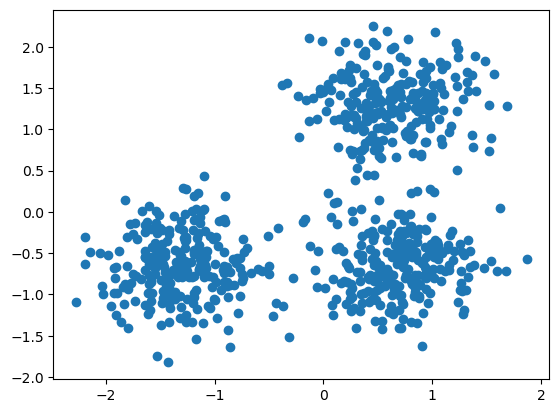

Estimated number of clusters: 3
Estimated number of noise points: 18
Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


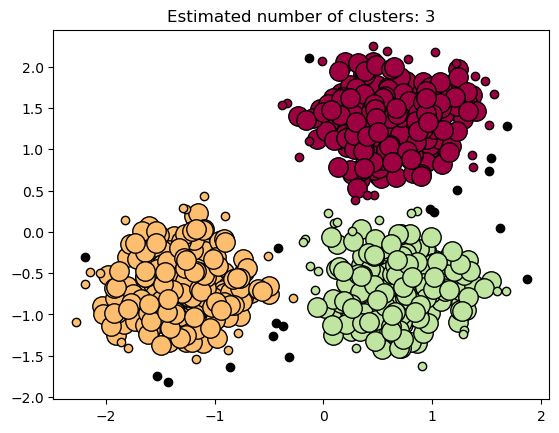

In [135]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

### Exemple complet DB-SCAN

Ho farem amb un altre dataset sintètic amb formes molt diverses i solapades. 

In [136]:
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import DBSCAN

from sklearn import metrics

!rm complex8.arff
!wget https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/complex8.arff

rm: no se puede borrar 'complex8.arff': No existe el archivo o el directorio
--2026-07-27 18:00:44--  https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/complex8.arff
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.108.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 47276 (46K) [text/plain]
Guardando como: ‘complex8.arff’

complex8.arff       100%[===================>]  46,17K  --.-KB/s    en 0,01s   

2026-07-27 18:00:44 (3,21 MB/s) - ‘complex8.arff’ guardado [47276/47276]



<class 'pandas.DataFrame'>
RangeIndex: 2551 entries, 0 to 2550
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       2551 non-null   float64
 1   y       2551 non-null   float64
 2   class   2551 non-null   object 
dtypes: float64(2), object(1)
memory usage: 59.9+ KB


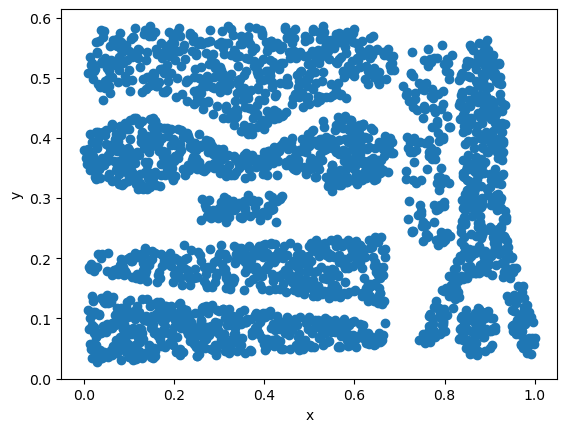

In [142]:
valores, metad = arff.loadarff("complex8.arff")
df = pd.DataFrame(valores)
df.info()
atr_x = "x"
atr_y= "y"

df['class'] = df['class'].str.decode("utf-8")
labels_true = df["class"]
df = df.drop(["class"], axis=1)
df = (df-np.min(df))/(np.max(df)-np.min(df))

x=df[atr_x]
y=df[atr_y]

plt.scatter(x, y)
plt.xlabel(atr_x)
plt.ylabel(atr_y)
plt.show()




Número de clusters: 110
Número de outliers: 1580


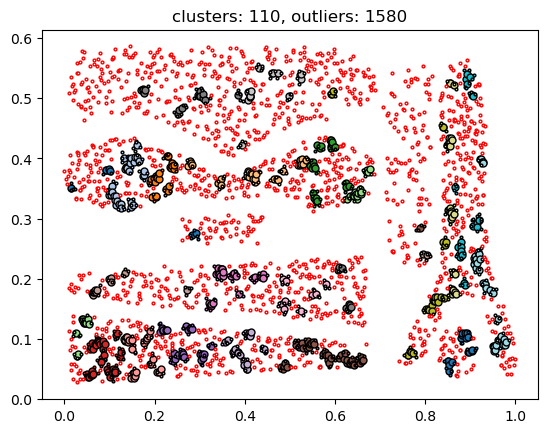

In [144]:
minPts = 5
epsilon = 0.01
db = DBSCAN(eps=epsilon, min_samples=minPts).fit(df[[atr_x,atr_y]])
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Número de clusters: %d" % n_clusters_)
print("Número de outliers: %d" % n_noise_)

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.tab20(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        #col = [0, 0, 0, 1]
        # Blanco con borde rojo para outliers
        col = [1, 1, 1, 1]

    class_member_mask = labels == k

    xy = df[class_member_mask & core_samples_mask]
    plt.plot(
        xy[atr_x],
        xy[atr_y],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=5,
    )

    xy = df[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[atr_x],
        xy[atr_y],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor= ("r" if k==-1 else "k"),
        markersize=2,
    )

plt.title(f"clusters: {n_clusters_}, outliers: {n_noise_}")
plt.show()

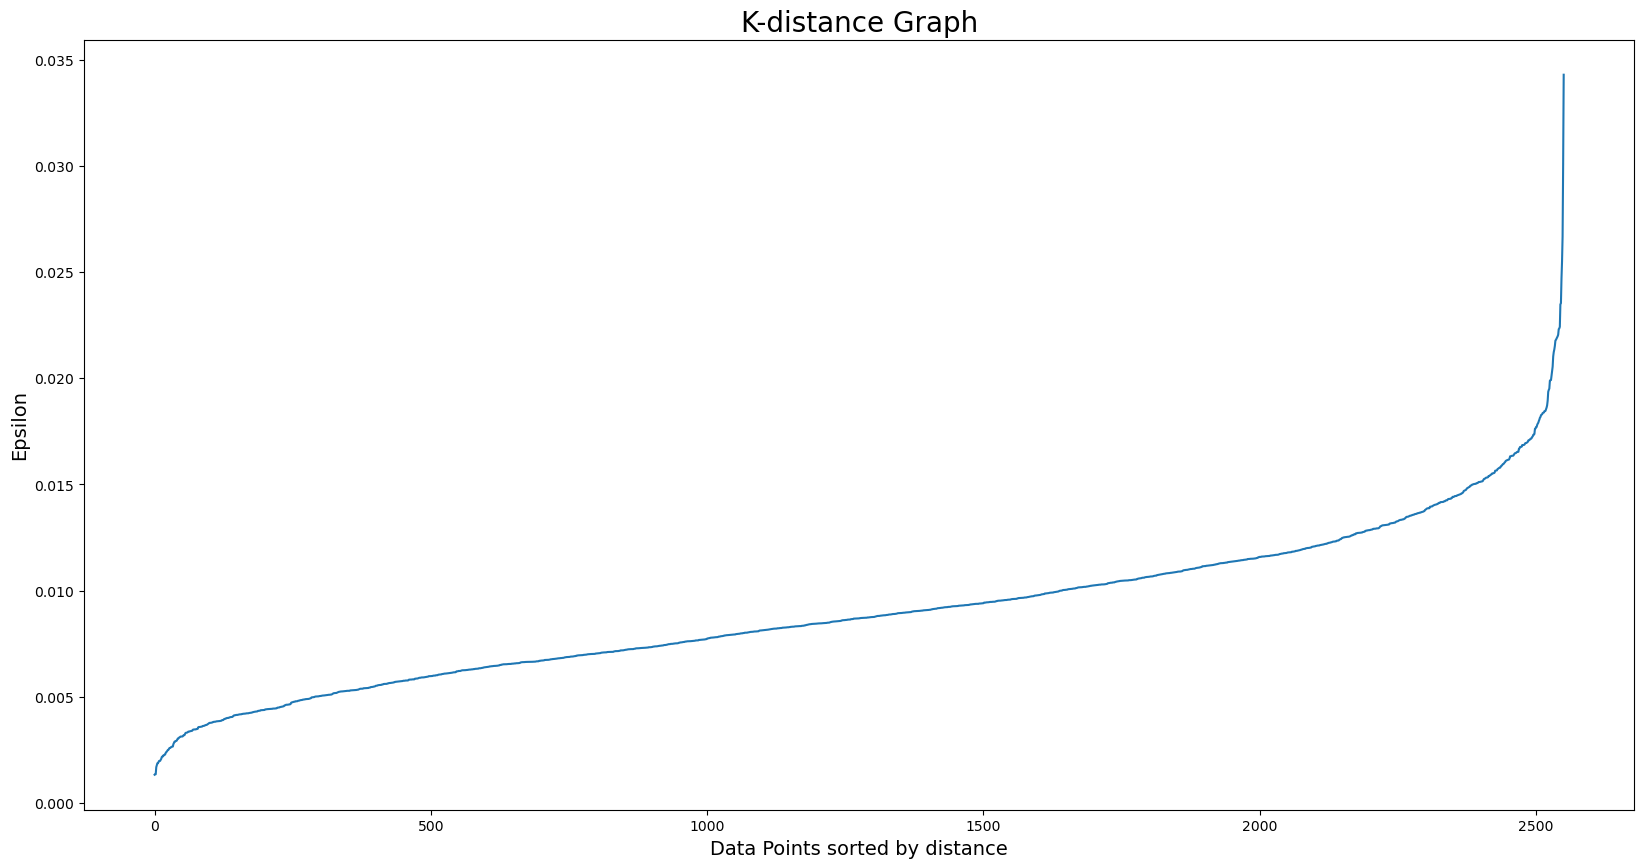

Codo: minPts= 5 , epsilon 0.030083579565779516


In [ ]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=minPts-1)
nbrs = neigh.fit(df)
distances, indices = nbrs.kneighbors()

# Plotting K-distance Graph
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(20,10))
plt.plot(distances)
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14)
plt.show()

# La segona derivada no va a funcionar bé amb aquest conjunt de dades, ja que la corba no és prou suau. Per tant, caldrà ajustar manualment el valor de epsilon.

abs_der2 = [0, 0]
for i in range(2, len(distances)-1):
  abs_der2.append(np.abs(2*distances[i]-distances[i+1]-distances[i-1]))
elbowX = pd.Series(abs_der2).idxmax() + 1

epsilon = distances[elbowX]

print("Codo: minPts=", minPts, ", epsilon", epsilon)

In [ ]:
db = DBSCAN(eps=0.025, min_samples=minPts).fit(df[[atr_x,atr_y]]) 
labels = db.labels_

# Number of clusters in labels, ignorng noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Número de clusters: %d" % n_clusters_)
print("Número de outliers: %d" % n_noise_)


Número de clusters: 8
Número de outliers: 3


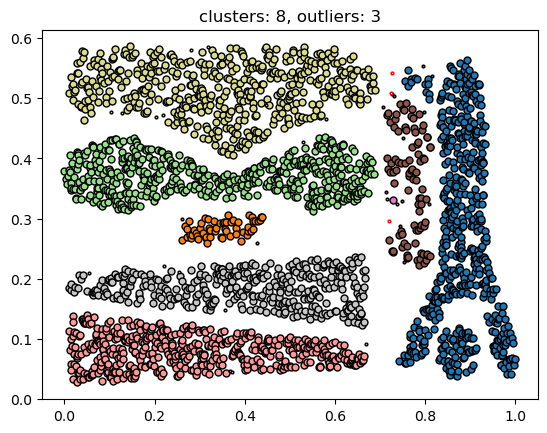

In [155]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.tab20(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        #col = [0, 0, 0, 1]
        # Blanco con borde rojo para outliers
        col = [1, 1, 1, 1]

    class_member_mask = labels == k

    xy = df[class_member_mask & core_samples_mask]
    plt.plot(
        xy[atr_x],
        xy[atr_y],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=5,
    )

    xy = df[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[atr_x],
        xy[atr_y],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor= ("r" if k==-1 else "k"),
        markersize=2,
    )

plt.title(f"clusters: {n_clusters_}, outliers: {n_noise_}")
plt.show()

A `scikit-learn` trobarem altres algorismes de la mateixa familia que `BDSCAN` com `OPTICS` o `HDBSCAN` que relaxen `eps` per trobar clusters de distintes densitats i apliquen altres optimitzacions, generalment amb un major cost computacional.  

## Clustering Jeràrquic

L'agrupació jeràrquica és una família general d'algoritmes d'agrupació que construeixen clústers imbricats fusionant-los o dividint-los successivament. Aquesta jerarquia de clústers es representa com un arbre (o dendrograma). L'arrel de l'arbre és l'únic clúster que recull totes les mostres, i les fulles són els clústers amb només una mostra.

Hi ha dos plantejaments per obtenir un clustering jeràrquic:
* Aglomeratiu. És un plantejament bottom-up o de baix a dalt. Es comença amb un clúster per cada dada, ia cada pas s'agrupen dos o més clústers existents en un de nou.
* Divisiu. És un plantejament top-down o de dalt a baix. Es comença amb un cluster per a totes les dades, ia cada pas es divideixen clusters existents en dos o més nous.
Hi ha diferents tipus de distància que es poden utilitzar, més o menys apropiades segons el dataset amb què es treballa. Però la més habitualment utilitzada és la distància euclidiana.

Un avantatge molt important del clustering jeràrquic és que els resultats són molt interpretables, i
a més a més a diversos nivells de detall. 

L'objecte `AgglomerativeClustering` realitza una agrupació jeràrquica mitjançant un enfocament ascendent: cada observació comença en el seu propi clúster i els clústers es fusionen successivament. El criteri d'enllaç determina la mètrica utilitzada per a l'estratègia de fusió:

* `Ward` minimitza la suma de les diferències al quadrat dins de tots els clústers. És un enfocament de minimització de la variància i, en aquest sentit, és similar a la funció objectiu k-means, però s'aborda amb un enfocament jeràrquic aglomeratiu. És el millor en la majoria de casos i amb soroll.
* L'enllaç màxim o complet minimitza la distància màxima entre observacions de parells de clústers.
* L'enllaç mitjà minimitza la mitjana de les distàncies entre totes les observacions de parells de clústers.
* L'enllaç únic minimitza la distància entre les observacions més properes de parells de clústers. Funciona bé amb clusters no globulars.

https://scikit-learn.org/stable/auto_examples/cluster/plot_linkage_comparison.html#sphx-glr-auto-examples-cluster-plot-linkage-comparison-py

## Gaussian Mixture Models (GMM)

Un model de mescla gaussiana és un model probabilístic que assumeix que tots els punts de dades es generen a partir d'una mescla d'un nombre finit de distribucions gaussianes amb paràmetres desconeguts. Es pot pensar en els models de mescles com la generalització de l'agrupació de k-means per incorporar informació sobre l'estructura de covariància de les dades, així com els centres de les gaussianes latents.

https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html#sklearn.mixture.GaussianMixture 

l'Hiperparàmetre interessant és `covariance_type` que pot ser:

* **full** Cada component una matriu particular de covariància.
* **tied** Tots els components tenen una mateixa matriu de covariància.
* **diag** Cada component una matriu diagonal de covariància.
* **spherical** Cada component té la seua varianza simple. 

> **Què és una matriu de covariància?** Si pensem en `K-Means` en termes de mitjana i variància, aquest estableix un centre del grup i unes distàncies respecte a la mitjana. El clúster és, per tant, un cercle, esfera o hiperesfera perfecta. En el cas de GMM, la matriu descriu cóm és una elipse a traves de tres valors: `Variància en X`, `Variància en Y` i `Covariància X,Y`. En el cas de més dimensions i ha una variància en cadascuna i les covariàncies creuades. La covariància entre una dimensió i una altra indica si les variables tenen alguna relació, per exemple, si augmenta la X, augmenta la Y i, per tant, la elipse queda inclinada.  

Per triar la correcta es pot utilitzar `GridSearchCV`. Per entendre intuïtivament cóm funcionen poden analitzar el següent exemple del propi tutorial oficial:


(150, 4)
spherical [0.08346342 0.14475912 0.17253752]
diag [[0.13005213 0.15525301 0.03640714 0.01214125]
 [0.14989432 0.07263568 0.21423722 0.02807828]
 [0.3538362  0.08705482 0.33371965 0.08884241]]
tied [[0.23772127 0.07160077 0.16394324 0.03154662]
 [0.07160077 0.10804638 0.03703032 0.01765452]
 [0.16394324 0.03703032 0.21936839 0.04469879]
 [0.03154662 0.01765452 0.04469879 0.03450936]]
full [[[0.13005213 0.1026954  0.01660336 0.00943024]
  [0.1026954  0.15525301 0.01002191 0.00560263]
  [0.01660336 0.01002191 0.03640714 0.00684441]
  [0.00943024 0.00560263 0.00684441 0.01214125]]

 [[0.18921315 0.05921808 0.12667096 0.03613148]
  [0.05921808 0.0689509  0.07048931 0.03667353]
  [0.12667096 0.07048931 0.17666081 0.05059027]
  [0.03613148 0.03667353 0.05059027 0.02770994]]

 [[0.35702637 0.08919948 0.29316704 0.06561403]
  [0.08919948 0.12043709 0.09670385 0.06075223]
  [0.29316704 0.09670385 0.34401368 0.0941349 ]
  [0.06561403 0.06075223 0.0941349  0.10418695]]]


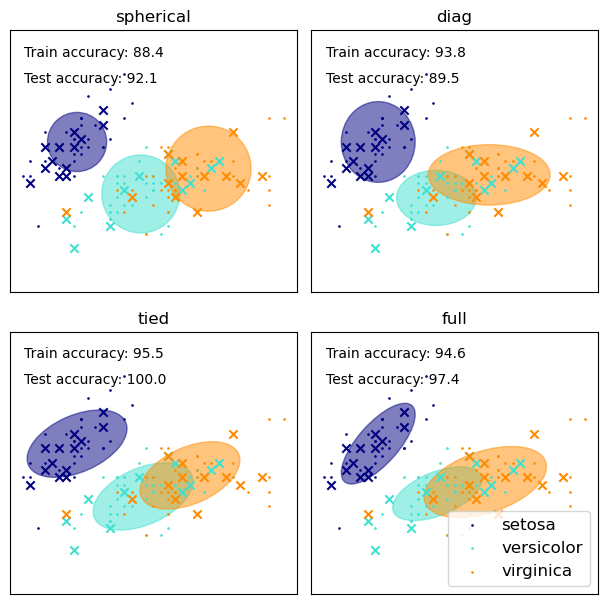

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold

colors = ["navy", "turquoise", "darkorange"]

# Observem cóm agafa la de les elipses de la covariància de cada component del GMM. Això és útil per visualitzar la forma de cada clúster.
def make_ellipses(gmm, ax):
    for n, color in enumerate(colors):
        if gmm.covariance_type == "full":
            covariances = gmm.covariances_[n][:2, :2]
        elif gmm.covariance_type == "tied":
            covariances = gmm.covariances_[:2, :2] # Dibuixa les 2 primeres dimensions de la covariància compartida entre tots els components
        elif gmm.covariance_type == "diag":
            covariances = np.diag(gmm.covariances_[n][:2])
        elif gmm.covariance_type == "spherical":
            covariances = np.eye(gmm.means_.shape[1]) * gmm.covariances_[n]
        v, w = np.linalg.eigh(covariances)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180 * angle / np.pi  # convert to degrees
        v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
        ell = mpl.patches.Ellipse(
            gmm.means_[n, :2], v[0], v[1], angle=180 + angle, color=color
        )
        ell.set_clip_box(ax.bbox)
        ell.set_alpha(0.5)
        ax.add_artist(ell)
        ax.set_aspect("equal", "datalim")


iris = datasets.load_iris()

print(iris.data.shape)

# Break up the dataset into non-overlapping training (75%) and testing
# (25%) sets.
skf = StratifiedKFold(n_splits=4)
# Only take the first fold.
train_index, test_index = next(iter(skf.split(iris.data, iris.target)))


X_train = iris.data[train_index]
y_train = iris.target[train_index]
X_test = iris.data[test_index]
y_test = iris.target[test_index]

n_classes = len(np.unique(y_train))

# Try GMMs using different types of covariances.
estimators = {
    cov_type: GaussianMixture(
        n_components=n_classes, covariance_type=cov_type, max_iter=20, random_state=0
    )
    for cov_type in ["spherical", "diag", "tied", "full"]
}

n_estimators = len(estimators)

plt.figure(figsize=(3 * n_estimators // 2, 6))
plt.subplots_adjust(
    bottom=0.01, top=0.95, hspace=0.15, wspace=0.05, left=0.01, right=0.99
)


for index, (name, estimator) in enumerate(estimators.items()):
    # Since we have class labels for the training data, we can
    # initialize the GMM parameters in a supervised manner.
    estimator.means_init = np.array(
        [X_train[y_train == i].mean(axis=0) for i in range(n_classes)]
    )

    # Train the other parameters using the EM algorithm.
    estimator.fit(X_train)

    h = plt.subplot(2, n_estimators // 2, index + 1)
    make_ellipses(estimator, h)

    for n, color in enumerate(colors):
        data = iris.data[iris.target == n]
        plt.scatter( # Dibuixa les 2 primeres dimensions de les dades d'entrenament amb punts circulars
            data[:, 0], data[:, 1], s=0.8, color=color, label=iris.target_names[n]
        )
    # Plot the test data with crosses
    for n, color in enumerate(colors):
        data = X_test[y_test == n]
        plt.scatter(data[:, 0], data[:, 1], marker="x", color=color)

    y_train_pred = estimator.predict(X_train)
    train_accuracy = np.mean(y_train_pred.ravel() == y_train.ravel()) * 100
    plt.text(0.05, 0.9, "Train accuracy: %.1f" % train_accuracy, transform=h.transAxes)

    y_test_pred = estimator.predict(X_test)
    test_accuracy = np.mean(y_test_pred.ravel() == y_test.ravel()) * 100
    plt.text(0.05, 0.8, "Test accuracy: %.1f" % test_accuracy, transform=h.transAxes)

    plt.xticks(())
    plt.yticks(())
    plt.title(name)

    print(estimator.covariance_type, estimator.covariances_)

plt.legend(scatterpoints=1, loc="lower right", prop=dict(size=12))


plt.show()

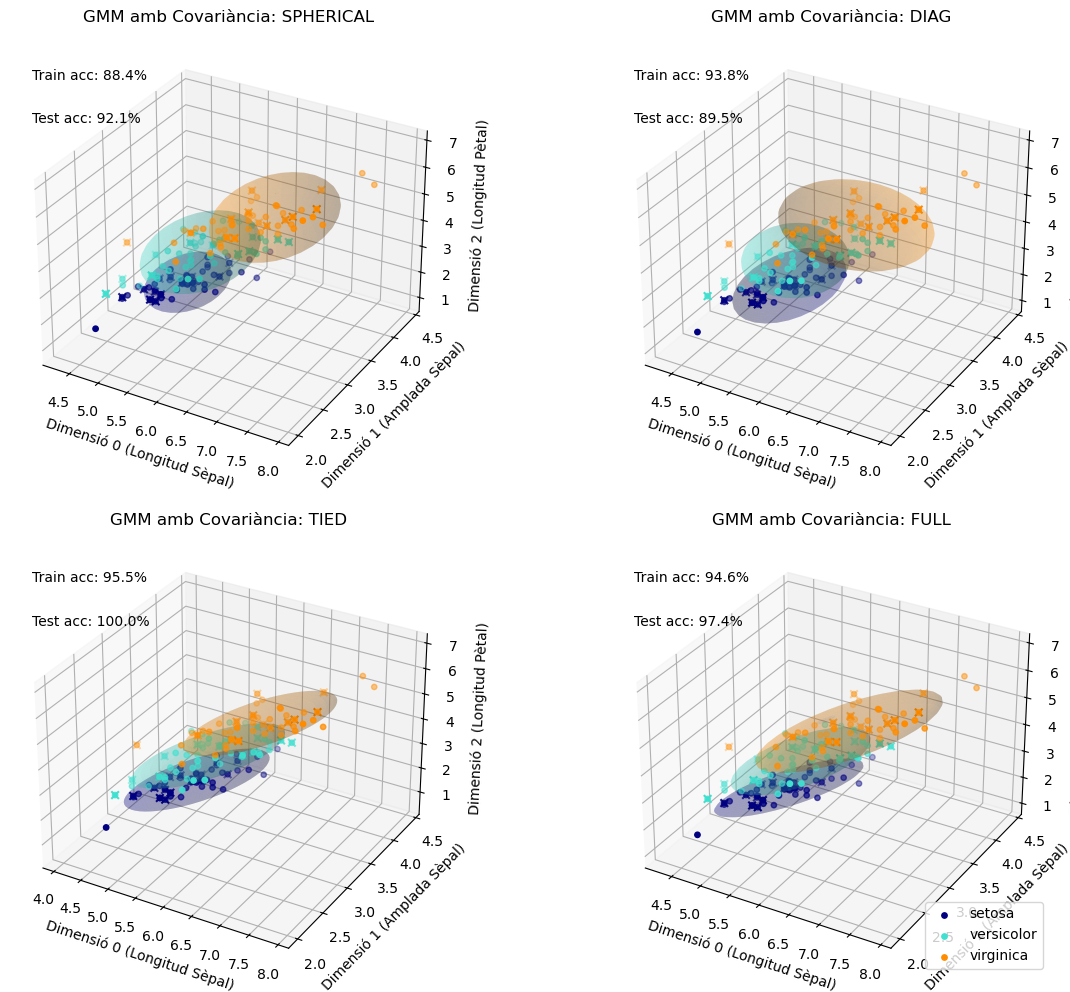

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold

colors = ["navy", "turquoise", "darkorange"]

def make_ellipsoids(gmm, ax):
    """
    Dibuixa el·lipsoides 3D basats en la matriu de covariància de cada component.
    """
    for n, color in enumerate(colors):
        # 1. Extreure la submatriu 3x3 per a les 3 primeres dimensions
        if gmm.covariance_type == "full":
            covariances = gmm.covariances_[n][:3, :3]
        elif gmm.covariance_type == "tied":
            covariances = gmm.covariances_[:3, :3]
        elif gmm.covariance_type == "diag":
            covariances = np.diag(gmm.covariances_[n][:3])
        elif gmm.covariance_type == "spherical":
            covariances = np.eye(3) * gmm.covariances_[n]
            
        mean = gmm.means_[n, :3]
        
        # 2. Descomposició en valors propis per saber l'escala i rotació
        U, s, rotation = np.linalg.svd(covariances)
        
        # 3. Generar una esfera unitària base amb coordenades esfèriques
        u = np.linspace(0.0, 2.0 * np.pi, 30)
        v = np.linspace(0.0, np.pi, 30)
        x = np.outer(np.cos(u), np.sin(v))
        y = np.outer(np.sin(u), np.sin(v))
        z = np.outer(np.ones_like(u), np.cos(v))
        
        # Apilar els punts per aplicar transformacions lineals fàcilment
        sphere_points = np.stack((x, y, z)).reshape(3, -1)
        
        # 4. Deformar l'esfera: escalar i rotar amb la covariància
        # Multipliquem per 2.0 la desviació estàndard per incloure més volum de dades
        transform_matrix = U @ np.diag(2.0 * np.sqrt(s))
        ellipsoid_points = transform_matrix @ sphere_points
        
        # 5. Desplaçar a la posició de la mitjana (centroide) i recuperar la forma de malla
        X = ellipsoid_points[0, :].reshape(30, 30) + mean[0]
        Y = ellipsoid_points[1, :].reshape(30, 30) + mean[1]
        Z = ellipsoid_points[2, :].reshape(30, 30) + mean[2]
        
        # 6. Dibuixar la superfície
        ax.plot_surface(X, Y, Z, color=color, alpha=0.2, linewidth=0, antialiased=True)

# Carregar dades
iris = datasets.load_iris()

# Dividir en Train (75%) i Test (25%)
skf = StratifiedKFold(n_splits=4)
train_index, test_index = next(iter(skf.split(iris.data, iris.target)))

X_train = iris.data[train_index]
y_train = iris.target[train_index]
X_test = iris.data[test_index]
y_test = iris.target[test_index]

n_classes = len(np.unique(y_train))

# Configurar els diferents GMMs
estimators = {
    cov_type: GaussianMixture(
        n_components=n_classes, covariance_type=cov_type, max_iter=20, random_state=0
    )
    for cov_type in ["spherical", "diag", "tied", "full"]
}

n_estimators = len(estimators)

# Configurar la figura global
fig = plt.figure(figsize=(12, 10))
plt.subplots_adjust(bottom=0.01, top=0.95, hspace=0.15, wspace=0.05, left=0.01, right=0.99)

for index, (name, estimator) in enumerate(estimators.items()):
    
    # Inicialització supervisada de les mitjanes
    estimator.means_init = np.array(
        [X_train[y_train == i].mean(axis=0) for i in range(n_classes)]
    )
    estimator.fit(X_train)

    # Crear el subplot en mode 3D
    ax = fig.add_subplot(2, n_estimators // 2, index + 1, projection='3d')
    
    # Dibuixar els el·lipsoides de covariància en 3D
    make_ellipsoids(estimator, ax)

    # Dibuixar les dades d'entrenament (Cercle) utilitzant les primeres 3 variables
    for n, color in enumerate(colors):
        data = iris.data[iris.target == n]
        ax.scatter(
            data[:, 0], data[:, 1], data[:, 2], s=15, color=color, label=iris.target_names[n]
        )
        
    # Dibuixar les dades de prova (Creu)
    for n, color in enumerate(colors):
        data = X_test[y_test == n]
        ax.scatter(data[:, 0], data[:, 1], data[:, 2], marker="x", s=30, color=color)

    # Càlcul de precisió
    y_train_pred = estimator.predict(X_train)
    train_accuracy = np.mean(y_train_pred.ravel() == y_train.ravel()) * 100
    
    y_test_pred = estimator.predict(X_test)
    test_accuracy = np.mean(y_test_pred.ravel() == y_test.ravel()) * 100

    # Textes en pantalla (en 3D s'ha d'utilitzar text2D per fixar-ho a la pantalla i no a l'espai 3D)
    ax.text2D(0.05, 0.9, f"Train acc: {train_accuracy:.1f}%", transform=ax.transAxes, fontsize=10)
    ax.text2D(0.05, 0.8, f"Test acc: {test_accuracy:.1f}%", transform=ax.transAxes, fontsize=10)

    ax.set_title(f"GMM amb Covariància: {name.upper()}", pad=10)
    
    # Etiquetes dels eixos
    ax.set_xlabel('Dimensió 0 (Longitud Sèpal)')
    ax.set_ylabel('Dimensió 1 (Amplada Sèpal)')
    ax.set_zlabel('Dimensió 2 (Longitud Pètal)')

# Treure la llegenda només al darrer gràfic
ax.legend(scatterpoints=1, loc="lower right", prop=dict(size=10))

plt.show()

GMM És més sofisticat que K-Means, però igualment confia en una certa globularitat dels clústers. Amb clústers convexos com les `moons` tindrà problemes similars. De fet `K-Means` es podria considerar un cas particular de `GMM` de tipus `spherical`i amb una probabilitat 100%. 

Al contrari que K-Means, GMM té un `soft assignment` i calcula la probabilitat de pertànyer a un grup. Utilitza algorismes més lents i pesats. Al igual que `K-Means`, necessita varis `n_init` per a no caure en mínims locals. Pot patir `Overfitting` en mode `full`. 

Per triar el `k` es pot servir de criteris com `AIC` o `BIC`, que són dos criteris disponibles al model entrenat: https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html#sphx-glr-auto-examples-mixture-plot-gmm-selection-py  

## Validació, mètriques i càlcul d'Hiperparàmetres



## Reducció de la dimensionalitat

Els algorismes de clustering són molt costosos computacionalment.

És molt típic que un algorisme de clustering tinga que considerar tots els parells de punts
d'un dataset. Si el nombre de punts és N, el nombre de possibles parells de punts és N · (N-1) / 2 =
N²/2 – N/2. Això és inassumible si, com sol ser el cas, es tenen datasets amb milers o milions de
observacions. 

Aquesta complexitat es multiplica amb el nombre d atributs o dimensionalitat el dataset. Perquè
el nombre d'operacions necessàries per al càlcul de la distància entre dos punts es multiplica
pel nombre d'atributs.
Per això, s'imposa la necessitat de reduir el nombre de dimensions del dataset. El planteja-
ment general d'aquestes tècniques és treballar amb un dataset de dimensionalitat menor que l'original, però que tot i així preservi la informació més rellevant.

Amb un dataset de molt alta dimensionalitat se solen plantejar els problemes següents.
* El cost computacional creix significativament conforme més gran és la dimensionalitat del
dataset.
* El que és pitjor, la pròpia qualitat dels resultats disminueix, pel fet que gran part dels resultats
atributs no són útils, perquè els seus valors segueixen una distribució en gran mesura alea-
tòria i no subjecta a cap regla o sistema. És a dir, que en comptes d'informació útil aporten
soroll (noise).
Hi ha moltes tècniques de reducció de la dimensionalitat. Però segurament la més important és
l'anàlisi de components principals, que es veu a continuació.

### PCA

L'anàlisi de components principals (`PCA` o `Principal Component Analysis`) és un mètode de reducció de la dimensionalitat amb què se substitueix el conjunt de variables o atributs d'un dataset per
un compost de components principals, més reduït, però que explica una part de la variància conjunta
ta del conjunt de variables originals. Aquesta part és més gran com més components principals es
considerin.

El conjunt de components principals { c1, c2,…, cP } té les propietats següents:
* Els components principals c1, c2,…, cP són ortogonals (és a dir, perpendiculars) entre si.
* Cada component principal explica o aporta una part (un percentatge) de la variància conjunta del
dataset. Aquest percentatge és el pes de la component principal. El pes de la primera és el més gran, i
els pesos per a les següents van en ordre decreixent.
* La suma dels pesos per a totes les components principals és 1. És a dir, les P components principals expliquen el 100% de la variància conjunta del dataset.

Cal recalcar que l'anàlisi de components principals es pot aplicar no només a problemes de
clustering, sinó també de classificació i de regressió. En definitiva, es tracta de substituir el dataset original
per un amb menor dimensionalitat. En el cas d'aprenentatge supervisat (classificació i regressió), el
mètode d'anàlisi de components principals s'aplicarà sobre el conjunt d'atributs predictors. Al
cas de no supervisat, s'aplica sobre el conjunt complet d'atributs.

#### Exemple de PCA amb el dataset IRIS

https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_iris.html#sphx-glr-auto-examples-decomposition-plot-pca-iris-py

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


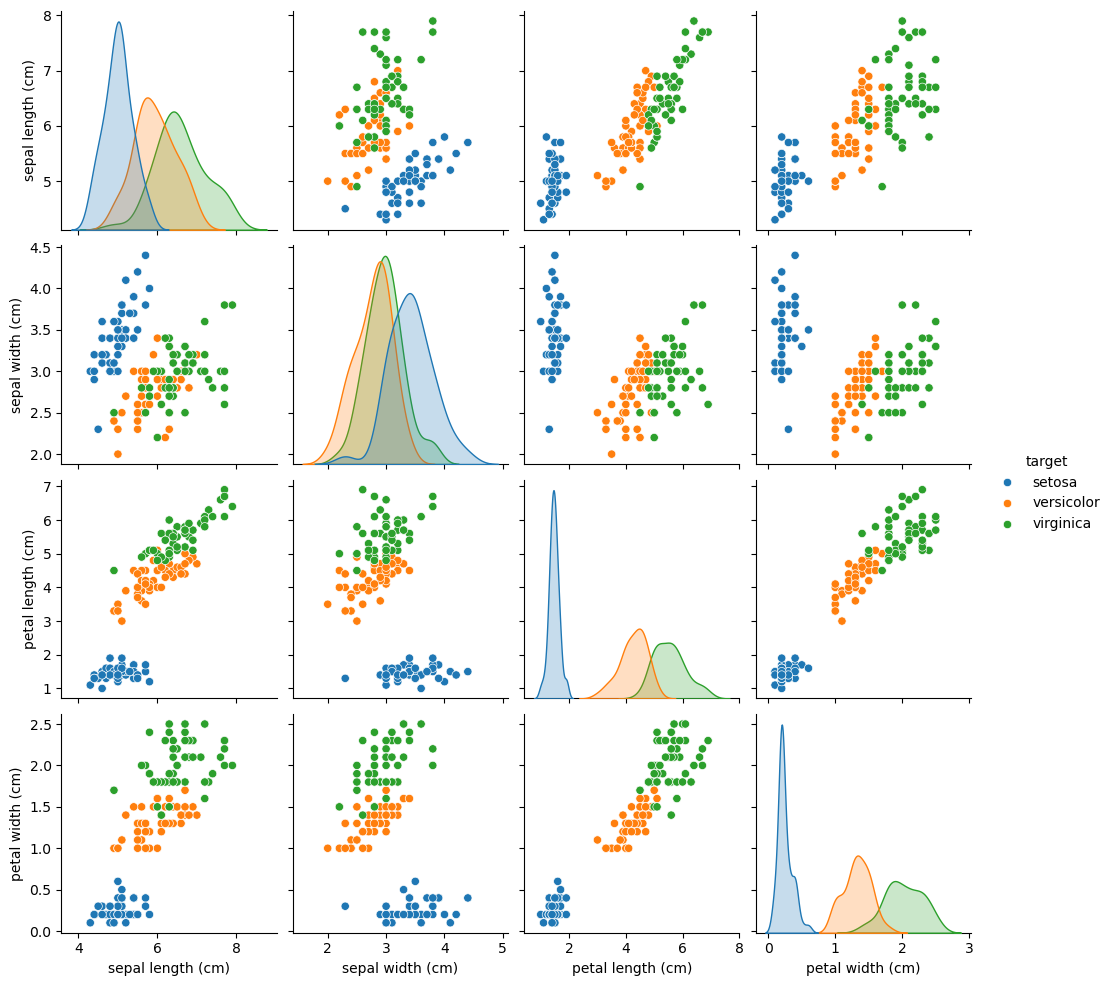

In [5]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
print(iris.keys())

import seaborn as sns

# Rename classes using the iris target names
iris.frame["target"] = iris.target_names[iris.target]
_ = sns.pairplot(iris.frame, hue="target")

Ja es pot veure un patró pel que fa al tipus Setosa, que és fàcilment identificable pel seu sèpal curt i ample. Només considerant aquestes dues dimensions, l'amplada i la longitud del sèpal, encara hi ha superposició entre els tipus Versicolor i Virginica.

La diagonal del diagrama mostra la distribució de cada característica. Observem que l'amplada i la longitud del pètal són les característiques més discriminants per als tres tipus.

Apliquem una anàlisi de components principals (ACP) al conjunt de dades de l'iris i, a continuació, representem gràficament els iris a través dels tres primers components principals. Això ens permetrà diferenciar millor entre els tres tipus!

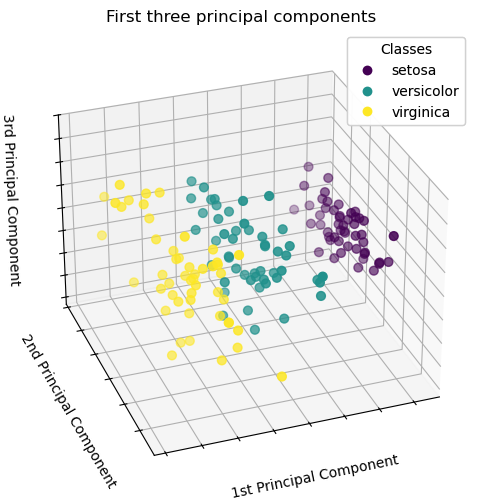

In [10]:
import matplotlib.pyplot as plt

# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401

from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

pca = PCA(n_components=3)

X_reduced = pca.fit_transform(iris.data)


scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=iris.target,
    s=40,
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    iris.target_names.tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

[0.92461872 0.05306648 0.01710261]


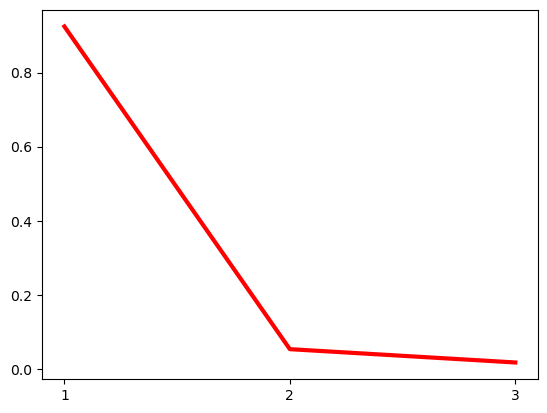

In [ ]:
# Es veu que el primer component principal explica la major part de la variància, i el segon component explica una mica més. El tercer component explica molt poca variància.
print(pca.explained_variance_ratio_)
# Gràfic de la proporció de variància explicada per cada component principal
plt.xticks(np.arange(1,pca.n_components+1,1))
plt.plot(np.arange(1,pca.n_components+1,1),pca.explained_variance_ratio_, color="red", linewidth=3)

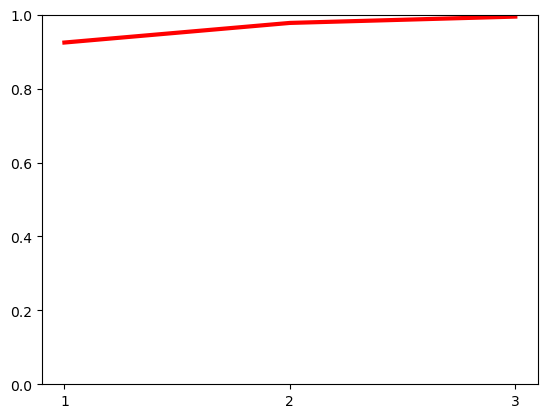

In [16]:
# Gráfico de proporción acumulada de varianza total explicada por componentes principales, llega a 1
expl_var_acum = []
var_acum = 0
for v in pca.explained_variance_ratio_:
    var_acum += v
    expl_var_acum.append(var_acum)
plt.ylim(0,1)
plt.xticks(np.arange(1,pca.n_components+1,1))
plt.plot(np.arange(1,pca.n_components+1,1),
expl_var_acum, color="red", linewidth=3,)

L'ACP crearà 3 noves característiques que són una combinació lineal de les 4 característiques originals. A més, aquesta transformació maximitza la variància. Amb aquesta transformació, podem identificar cada espècie utilitzant només el primer component principal.



### Multidimensional Scaling (MDS)

https://scikit-learn.org/stable/modules/manifold.html#multidimensional-scaling

El principal problema de `PCA` és que necessita que les dades tinguen correlació lineal. Aquests algorismes formen part d'un conjunt anomenat `Manifold Learning` que intenta generalitzar algorismes com el `PCA` per a dades no lineals. 

`MDS` es basa en les distàncies. En la representació en poques dimensions resultant, les distàncies són aproximadament les mateixes que en l'espai de moltes dimensions. Es considera que les dades no similars tenen més distància `euclidiana`.

No és adequat generalment com a preprocesament per no tenir funció de transformació i ser costós computacionalment. És útil per a representar les dades en l'anàlisi anterior per detectar outliers o grups de dades. 



### t-Distributed Stochastic Neighbor Embedding (t-SNE)

També organitza per distàncies però dona més importància a les distàncies curtes. D'aquesta manera revetla afinitats locals entre punts de dades. 

Es tracta d'un algorisme computacionalment car i estocàstic. Si s'inicialitzen els punts en PCA respecta millor l'estructura global. 

No és un algorisme adequat per a reduir les dades per a entrenament de models ni en producció ja que no generen una funció de transformació com el PCA per a dades noves, les dades noves provoquen regenerar de nou. Pot servir per confirmar visualment que les classes están separades en entorns de moltes dimensions abans d'entrenar. N 

### Autoencoders

Els **autoencoders** són una de les eines més potents i utilitzades per a la reducció de dimensionalitat, especialment quan parlem de dades complexes o no lineals.

Un autoencoder és un tipus de xarxa neuronal artificial no supervisada que té un objectiu molt senzill: **aprendre a copiar la seva entrada a la seva sortida**. Però el secret de la seva utilitat per reduir dimensions està en la seva arquitectura:

* **El "Coll d'Ampolla" (*Bottleneck*):** L'arquitectura de la xarxa s'estreny pel mig, obligant-la a passar per una capa amb moltes menys neurones que l'entrada original. Per exemple, si passes d'un input de 784 dimensions (com una imatge de 28x28 píxels), la xarxa es veu obligada a comprimir tota aquesta informació en un vector molt més petit (per exemple, de 2 o 10 dimensions) a la seva capa central abans de tornar a reconstruir-la.
* **La part de compressió (Encoder):** Aquesta primera meitat de la xarxa és exactament un reductor de dimensionalitat. Agafa dades d'alta dimensió i les projecta en un espai latent de baixa dimensió.

**Superen la linealitat del PCA:** Mentre que el PCA només pot trobar relacions lineals per reduir dimensions, un autoencoder (en tenir capes ocultes no lineals amb funcions d'activació com ReLU) pot aprendre **patrons altament no lineals**, sent molt més potent en dades complexes (com imatges, àudio o textos). **Sí que serveixen per a producció (a diferència de t-SNE o MDS):** Un cop entrenes l'autoencoder, pots guardar la meitat de l'encoder i utilitzar-lo directament per transformar dades noves o de test de manera ràpida (igual que fas amb `.transform()` en PCA).


A scikit-learn, l'RBM apareix sota el nom de **`BernoulliRBM`** (dins del mòdul `sklearn.neural_network`). Vegem en què s'assemblen i en què es diferencien respecte als autoencoders:

On s'assemblen? (Per què estan relacionats)

1. **Són xarxes neuronals no supervisades amb "coll d'ampolla":** Igual que un autoencoder, un RBM té una capa d'entrada (visible) i una capa oculta amb menys dimensions (o un nombre de components diferent), dissenyada per aprendre a extreure característiques i comprimir la informació.
2. **Busquen reconstruir les dades:** L'objectiu de l'RBM és aprendre a modelar la distribució de les dades d'entrada intentant reconstruir-les a partir de la seva capa oculta mitjançant processos probabilístics.

On es diferencien? (Per què no són el mateix)

1. **Arquitectura i connexions:**
* Un **autoencoder** és una xarxa neuronal profunda o estàndard de flux endavant (*feed-forward*) que utilitza funcions d'activació convencionals (com ReLU o Sigmoide) i s'entrena mitjançant **retropropagació (*backpropagation*)** i descens de gradient clàssic.
* Un **RBM (Restricted Boltzmann Machine)** és un model gràfic probabilístic basat en energia. Té només dues capes (visible i oculta) on les neurones d'una mateixa capa no estan connectades entre si. No utilitza *backpropagation*, sinó un mètode d'aprenentatge estocàstic anomenat **Divergència Contrastiva (*Contrastive Divergence*)**.


2. **Restriccions de dades a Scikit-learn:**
* El `BernoulliRBM` de scikit-learn assumeix que les dades d'entrada són **binàries o valors entre 0 i 1** (probabilitats), ja que s'ajusta a distribucions de Bernoulli. Un autoencoder pot gestionar dades contínues, normals o de qualsevol tipus amb molta més flexibilitat depenent de la funció de pèrdua que triïs.



### Per a què s'utilitza l'RBM a Scikit-learn?

Històricament, abans del *boom* absolut de les xarxes profundes modernes, els RBM s'utilitzaven molt com a **pas previ d'entrenament (*pre-training*)** per inicialitzar els pesos d'una xarxa neuronal més gran o com a extractor de característiques. Per exemple, a scikit-learn sovint es combinen en un `Pipeline` passant les dades primer per un `BernoulliRBM` per extreure patrons i després per un classificador lineal (com una regressió logística o una SVM) per millorar-ne el rendiment.

Per a implementar **autoencoders** de manera professional, eficient i amb capacitat de escalar a models profunds, la llibreria estàndard de la indústria i la més adequada és **PyTorch** o **TensorFlow (amb Keras)**.

Scikit-learn no disposa d'una classe nativa per a autoencoders generals (l'únic que s'hi assembla lleugerament és el `BernoulliRBM` que hem vist, però està limitat a dades binàries i no és una xarxa neuronal profunda).

1. PyTorch (Recomanat per a recerca i flexibilitat)

Actualment és la llibreria preferida per la majoria de data scientists i investigadors.

* **Per què destaca:** Permet definir l'arquitectura de l'encoder i el decoder d'una manera molt intuïtiva orientada a objectes (`nn.Module`), i dona un control total sobre el bucle d'entrenament, les funcions de pèrdua (com MSE, Binary Cross-Entropy) i els optimitzadors (com Adam).

2. TensorFlow / Keras (Ideal per a productivitat i simplicitat)

Keras (integrat dins de TensorFlow) ofereix una sintaxi extremadament neta i ràpida per crear autoencoders amb molt poques línies de codi mitjançant la seva API funcional.

* **Per què destaca:** Si busques una integració ràpida i no vols complicar-te amb detalls de baix nivell del tensor, Keras ho fa molt senzill.

---

Exemple bàsic d'un Autoencoder en Keras (TensorFlow):

```python
from tensorflow.keras import layers, models

# 1. Definir l'arquitectura (Exemple: de 784 dimensions a un coll d'ampolla de 32)
input_layer = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation="relu")(input_layer)
bottleneck = layers.Dense(32, activation="relu")(encoded)  # Espai latent reduït

decoded = layers.Dense(128, activation="relu")(bottleneck)
output_layer = layers.Dense(784, activation="sigmoid")(decoded)

# 2. Construir el model complet
autoencoder = models.Model(input_layer, output_layer)
autoencoder.compile(optimizer="adam", loss="mse")

# 3. Entrenar (aprenent a reconstruir les pròpies dades X_train)
# autoencoder.fit(X_train, X_train, epochs=50, batch_size=256)

# 4. Extreure només la part de l'Encoder per reduir dimensionalitat
encoder = models.Model(input_layer, bottleneck)
# X_reduced = encoder.predict(X_test) # Dades reduïdes a 32 dimensions

```


Pots utilitzar l'encoder d'un autoencoder com un pas previ de transformació (igual que faries amb el `.transform()` d'un PCA) per reduir el nombre de dimensions de les teves dades, i després **passar aquesta nova representació de baixa dimensió (l'espai latent) com a dataset d'entrada per entrenar qualsevol model supervisat**, com una regressió lineal, una regressió logística o un model d'arbre.

### Avantatges d'aquesta combinació:

1. **Eliminació de soroll:** L'autoencoder aprèn a quedar-se només amb les característiques essencials i a ignorar el soroll aleatori de les dades originals. Això sovint fa que el model de regressió posterior sigui més robust i generalitzi millor.
2. **Gestió de relacions no lineals:** Si les teves dades tenen relacions complexes que un PCA (que és lineal) no pot capturar, l'autoencoder pot extreure característiques no lineals molt més riques per a la teva regressió.
3. **Reducció del cost computacional:** Si tens un dataset amb milers de columnes (per exemple, imatges o dades genòmiques), entrenar una regressió directament pot ser molt lent o patir de sobreajust (*overfitting*). Reduir-ho a un espai latent petit amb l'encoder simplifica molt la feina del model de regressió.

https://www.innovaciondigital360.com/i-a/que-son-los-autoencoders-y-como-funcionan/